# Previsão de Preços de Imóveis — Airbnb São Paulo
### MBA em Ciência de Dados — UNIFOR
**Disciplina:** Aprendizado de Máquina Supervisionado
**Professor:** Caio Ponte | **Turma:** 11

**Problema:** Regressão — prever o preço da diária (`price`) de anúncios do Airbnb em São Paulo
**Fonte dos dados:** [InsideAirbnb](https://insideairbnb.com/) — scrape de 20/06/2026


## Setup — Bibliotecas e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pd.set_option('display.max_columns', None)
%matplotlib inline


In [2]:
df = pd.read_csv('listings.csv', low_memory=False)
print('Shape original:', df.shape)
df.head(3)


Shape original: (42354, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,4917,https://www.airbnb.com/rooms/4917,20260614072545,2026-06-16,city scrape,Resort Condo Near Av. Paulista,"Comfortable 2 bedrooms (1 master suite), 2 bat...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,5618,https://www.airbnb.com/users/show/5618,1462506497915065828,https://www.airbnb.com/users/profile/146250649...,Alessandro,NaN,17,5,15,5,"Rome, Italy","Hi, I’m Alex, a Brazilian with Italian roots w...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User-...,NaN,69,NaN,NaN,t,t,NaN,Vila Mariana,Vila Mariana,-23.57419,-46.63973,Entire condo,Entire home/apt,4,2.0,2 baths,2.0,3.0,"[""Free washer \u2013 In unit"", ""Ethernet conne...",$540.43,2026-07-21,2026-08-04,7566.00,540.43,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",5.0,1125.0,5.0,21.0,1125.0,1125.0,19.4,1125.0,NaN,t,2,19,32,57,2026-06-16,65,5,0,56,5,50,27022.0,2014-11-10,2026-05-07,4.85,4.91,4.65,4.94,4.94,4.97,4.67,NaN,NaN,1,1,0,0,0.46
1,54614,https://www.airbnb.com/rooms/54614,20260614072545,2026-06-16,city scrape,Nice area/Cozy flat/ Building rooftop pool,"Small, modern and charming flat. Cozy standard...",NaN,https://a0.muscache.com/pictures/31da1f7a-2d33...,256576,https://www.airbnb.com/users/show/256576,1462513920747223748,https://www.airbnb.com/users/profile/146251392...,Lílian,NaN,15,8,15,5,"São Paulo, Brazil","Frelancer journalist and audiovisual producer,...",NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/6896e...,NaN,1,NaN,NaN,t,t,NaN,Santa Cecilia,Se,-23.54153,-46.65362,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Free washer \u2013 In unit"", ""Fire extinguis...",$289.04,2026-07-05,2026-08-04,8671.32,289.04,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",30.0,90.0,30.0,30.0,90.0,90.0,30.0,90.0,NaN,t,11,41,71,71,2026-06-16,209,1,1,71,0,60,17342.0,2015-12-14,2026-05-28,4.97,4.97,4.85,5.00,4.99,4.97,4.93,NaN,NaN,1,1,0,0,1.63
2,82935,https://www.airbnb.com/rooms/82935,20260614072545,2026-06-14,city scrape,Oscar Freire - Hospital das Clínicas e Nu Bank,I live in a 3-bedroom apartment in the most re...,NaN,https://a0.muscache.com/pictures/1cb69bb6-bb68...,451565,https://www.airbnb.com/users/show/451565,1462511917526407290,https://www.airbnb.com/users/profile/146251191...,Thaïs,NaN,15,2,15,2,"Sao Paulo, Brazil","My name is Thaïs, I love meeting people, 

---
## Etapa 1 — Definição do Problema

### Contexto
Os dados utilizados são públicos, disponibilizados pelo projeto **InsideAirbnb**, que realiza scraping periódico
de anúncios do Airbnb em diversas cidades do mundo. Utilizamos o scrape de **São Paulo, 20/06/2026**.

### Problema
Trata-se de um problema de **regressão**: o objetivo é prever o **preço da diária** (`price`) de um anúncio de
imóvel no Airbnb, a partir de suas características físicas, de localização, do anfitrião e de avaliações.

### O que cada amostra representa
**Cada linha do dataset representa um anúncio individual (um imóvel específico) publicado no Airbnb.**
Um mesmo anfitrião pode ter múltiplos anúncios (múltiplas linhas), cada um com seu próprio `id`, preço,
características e histórico de avaliações.

### Motivação
Prever o preço de um imóvel é útil tanto para **anfitriões** (precificação competitiva de novos anúncios)
quanto para a própria plataforma (sugestão automática de preço) e para **investidores** avaliando potencial
de rentabilidade de um imóvel antes de anunciá-lo.

### Origem e formato dos dados
- **Fonte:** data.insideairbnb.com/brazil/sp/sao-paulo
- **Formato original:** CSV compactado (`listings.csv.gz`)
- **Registros:** 42.354 anúncios
- **Colunas originais:** 90 (reduzidas para as relevantes — ver dicionário de dados)


### Dicionário de Dados (colunas selecionadas)

| Coluna | Tipo | Descrição | Uso |
|---|---|---|---|
| `price` | Numérico (R$) | Preço da diária do anúncio | **Target** |
| `room_type` | Categórico | Tipo de acomodação (inteira, privada, compartilhada, hotel) | Feature |
| `property_type` | Categórico | Tipo específico do imóvel | Feature |
| `accommodates` | Numérico | Capacidade de hóspedes | Feature |
| `bathrooms` / `bedrooms` / `beds` | Numérico | Cômodos do imóvel | Feature |
| `minimum_nights` / `maximum_nights` | Numérico | Estadia mín./máx. em noites | Feature |
| `latitude` / `longitude` | Numérico | Coordenadas geográficas | Feature |
| `neighbourhood_cleansed` | Categórico | Bairro do imóvel | Feature |
| `name` / `description` / `amenities` | Texto | Título, descrição e comodidades | Feature (via NLP) |
| `host_is_superhost` | Booleano | Se o anfitrião é "Superhost" | Feature |
| `host_listings_count` | Numérico | Nº de imóveis do anfitrião | Feature |
| `number_of_reviews` / `review_scores_*` | Numérico | Avaliações recebidas | Feature |
| `availability_30/60/90/365` | Numérico | Dias disponíveis | Feature |

**Colunas descartadas** (100% nulas): `host_response_time`, `host_acceptance_rate`, `host_verifications`,
`license`, `instant_bookable`. Também descartamos URLs e metadados de scraping, sem valor preditivo.


In [3]:
cols = [
    'id', 'price',
    'room_type', 'property_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights',
    'latitude', 'longitude', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
    'name', 'description', 'amenities',
    'host_is_superhost', 'host_since', 'host_listings_count',
    'host_identity_verified', 'host_has_profile_pic',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'review_scores_cleanliness', 'review_scores_location', 'review_scores_value',
    'availability_30', 'availability_60', 'availability_90', 'availability_365'
]
cols = [c for c in cols if c in df.columns]
df = df[cols].copy()

# Limpeza do price: remove '$' e ',' e converte para float
df['price'] = (df['price'].astype(str)
               .str.replace('$', '', regex=False)
               .str.replace(',', '', regex=False)
               .astype(float))

print('Shape após seleção de colunas:', df.shape)
df.head(3)


Shape após seleção de colunas: (42354, 32)


,id,price,room_type,property_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,latitude,longitude,neighbourhood_cleansed,neighbourhood_group_cleansed,name,description,amenities,host_is_superhost,host_since,host_listings_count,host_identity_verified,host_has_profile_pic,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,availability_30,availability_60,availability_90,availability_365
0,4917,540.43,Entire home/apt,Entire condo,4,2.0,2.0,3.0,5.0,1125.0,-23.57419,-46.63973,Vila Mariana,Vila Mariana,Resort Condo Near Av. Paulista,"Comfortable 2 bedrooms (1 master suite), 2 bat...","[""Free washer \u2013 In unit"", ""Ethernet conne...",t,NaN,69,t,t,65,0.46,4.85,4.65,4.97,4.67,2,19,32,57
1,54614,289.04,Entire home/apt,Entire rental unit,3,1.0,1.0,1.0,30.0,90.0,-23.54153,-46.65362,Santa Cecilia,Se,Nice area/Cozy flat/ Building rooftop pool,"Small, modern and charming flat. Cozy standard...","[""Free washer \u2013 In unit"", ""Fire extinguis...",f,NaN,1,t,t,209,1.63,4.97,4.85,4.97,4.93,11,41,71,71
2,82935,309.00,Private room,Private room in rental unit,1,1.0,NaN,1.0,1.0,1125.0,-23.55699,-46.67436,Jardim Paulista,Pinheiros,Oscar Freire - Hospital das Clínicas e Nu Bank,I live in a 3-bedroom apartment in the most re...,"[""Free street parking"", ""Coffee maker: Nespres...",t,NaN,1,t,t,107,0.61,4.94,4.97,4.98,4.86,0,26,56,326


---
## Etapa 2 — Análise Exploratória dos Dados (EDA)


### 2.1 — Distribuição do preço (target)

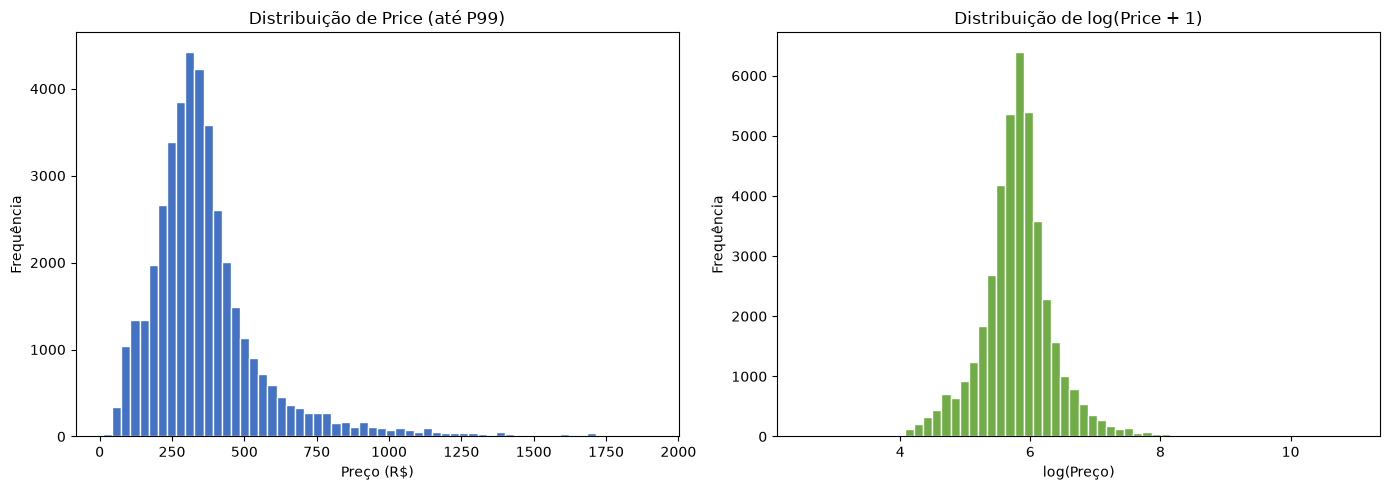

Skewness price bruto: 35.51
Skewness log(price): 0.7


In [4]:
price = df['price'].dropna()
price_sem_extremos = price[price <= price.quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(price_sem_extremos, bins=60, color='#4472C4', edgecolor='white')
axes[0].set_title('Distribuição de Price (até P99)')
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Frequência')

price_log = np.log1p(price)
axes[1].hist(price_log, bins=60, color='#70AD47', edgecolor='white')
axes[1].set_title('Distribuição de log(Price + 1)')
axes[1].set_xlabel('log(Preço)')
axes[1].set_ylabel('Frequência')
plt.tight_layout()
plt.show()

print('Skewness price bruto:', round(price.skew(), 2))
print('Skewness log(price):', round(price_log.skew(), 2))


**Conclusão:** o preço bruto tem assimetria extrema (skewness=35,5), causada por uma cauda longa de imóveis
de altíssimo valor. Aplicando `log(price+1)`, a distribuição se aproxima muito mais de uma normal
(skewness=0,70). Isso é relevante para a Etapa 4: modelos lineares tendem a se beneficiar de treinar sobre
`log(price)` em vez do preço bruto.

### 2.2 — Estatísticas descritivas

In [5]:
num_cols = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
            'minimum_nights', 'maximum_nights',
            'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
            'review_scores_cleanliness', 'review_scores_location', 'review_scores_value',
            'availability_30', 'availability_60', 'availability_90', 'availability_365',
            'host_listings_count']

desc = df[num_cols].describe().T
desc['nulos'] = df[num_cols].isna().sum()
desc['nulos_%'] = (df[num_cols].isna().sum() / len(df) * 100).round(2)
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,nulos,nulos_%
price,41832.0,418.05,817.57,11.53,250.00,331.00,429.50,57127.00,522,1.23
accommodates,42354.0,2.96,1.95,1.00,2.00,2.00,4.00,16.00,0,0.00
bathrooms,39855.0,1.18,0.64,0.50,1.00,1.00,1.00,20.00,2499,5.90
bedrooms,36688.0,1.23,0.77,0.00,1.00,1.00,1.00,46.00,5666,13.38
beds,41782.0,1.77,1.88,1.00,1.00,1.00,2.00,64.00,572,1.35
minimum_nights,42343.0,2.31,4.34,1.00,1.00,1.00,2.00,90.00,11,0.03
maximum_nights,42343.0,563.99,422.28,2.00,360.00,365.00,1125.00,1125.00,11,0.03
number_of_reviews,42354.0,37.22,66.70,0.00,3.00,14.00,44.00,3314.00,0,0.00
reviews_per_month,36583.0,1.96,2.03,0.01,0.60,1.40,2.70,73.21,5771,13.63
review_scores_rating,36583.0,4.77,0.40,0.00,4.73,4.89,5.00,5.00,5771,13.63


**Observações:**
- `bedrooms` (13,4%), `review_scores_*` (13,6%) e `bathrooms` (5,9%) têm proporção relevante de nulos → tratar na Etapa 3
- Valores máximos suspeitos (`bedrooms`=46, `bathrooms`=20, `beds`=64) indicam outliers extremos
- `review_scores_rating` tem mediana 4,89/5 — avaliações no Airbnb são geralmente infladas
- `host_listings_count`: média (64) muito acima da mediana (8) → distribuição concentrada em poucos "super anfitriões"


### 2.3 — Balanceamento de `room_type`

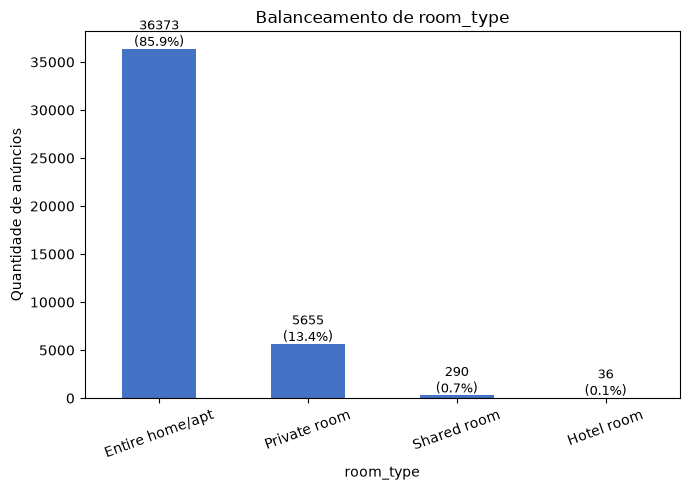

,mean,median,count
room_type,,,
Entire home/apt,438.22,343.0,35964
Hotel room,574.13,368.5,36
Private room,299.98,183.0,5545
Shared room,151.52,98.0,287


In [6]:
counts = df['room_type'].value_counts()
pct = (counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(7,5))
counts.plot(kind='bar', ax=ax, color='#4472C4')
ax.set_title('Balanceamento de room_type')
ax.set_ylabel('Quantidade de anúncios')
plt.xticks(rotation=20)
for i, v in enumerate(counts):
    ax.text(i, v + 300, f'{v}\n({pct.iloc[i]}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

df.groupby('room_type')['price'].agg(['mean','median','count']).round(2)


**Conclusão:** `room_type` é fortemente desbalanceado (85,9% "Entire home/apt"), mas carrega informação
real — imóveis inteiros custam, em média, quase 3x mais que quartos compartilhados. `Hotel room` tem apenas
36 amostras (0,1%), podendo ter comportamento instável no modelo.

### 2.4 — Outliers

C:\Users\luanv\AppData\Local\Temp\ipykernel_17764\1596108408.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
C:\Users\luanv\AppData\Local\Temp\ipykernel_17764\1596108408.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
C:\Users\luanv\AppData\Local\Temp\ipykernel_17764\1596108408.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
C:\Users\luanv\AppData\Local\Temp\ipykernel_17764\1596108408.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', '

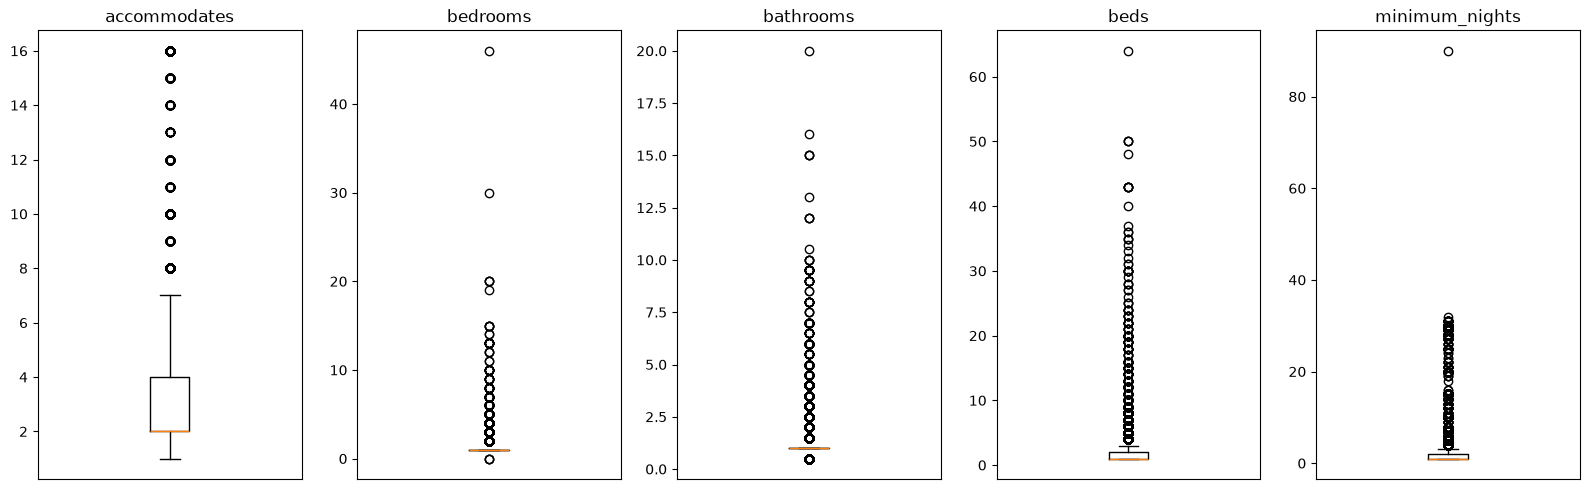

Registros extremos suspeitos:
bedrooms > 10: 29
bathrooms > 10: 10
beds > 20: 61
minimum_nights > 30: 34
accommodates > 10: 573


In [7]:
cols_outlier = ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'minimum_nights']

fig, axes = plt.subplots(1, len(cols_outlier), figsize=(16, 5))
for ax, col in zip(axes, cols_outlier):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_xticks([])
plt.tight_layout()
plt.show()

print('Registros extremos suspeitos:')
print('bedrooms > 10:', (df['bedrooms'] > 10).sum())
print('bathrooms > 10:', (df['bathrooms'] > 10).sum())
print('beds > 20:', (df['beds'] > 20).sum())
print('minimum_nights > 30:', (df['minimum_nights'] > 30).sum())
print('accommodates > 10:', (df['accommodates'] > 10).sum())


**Conclusão:** exceto `accommodates` (outliers mais numerosos, porém plausíveis — grupos grandes),
as demais variáveis têm outliers raríssimos (<0,15% dos dados cada). Serão tratados (capping ou remoção)
na Etapa 3, com impacto mínimo no volume de dados.

### 2.5 — Matriz de correlação

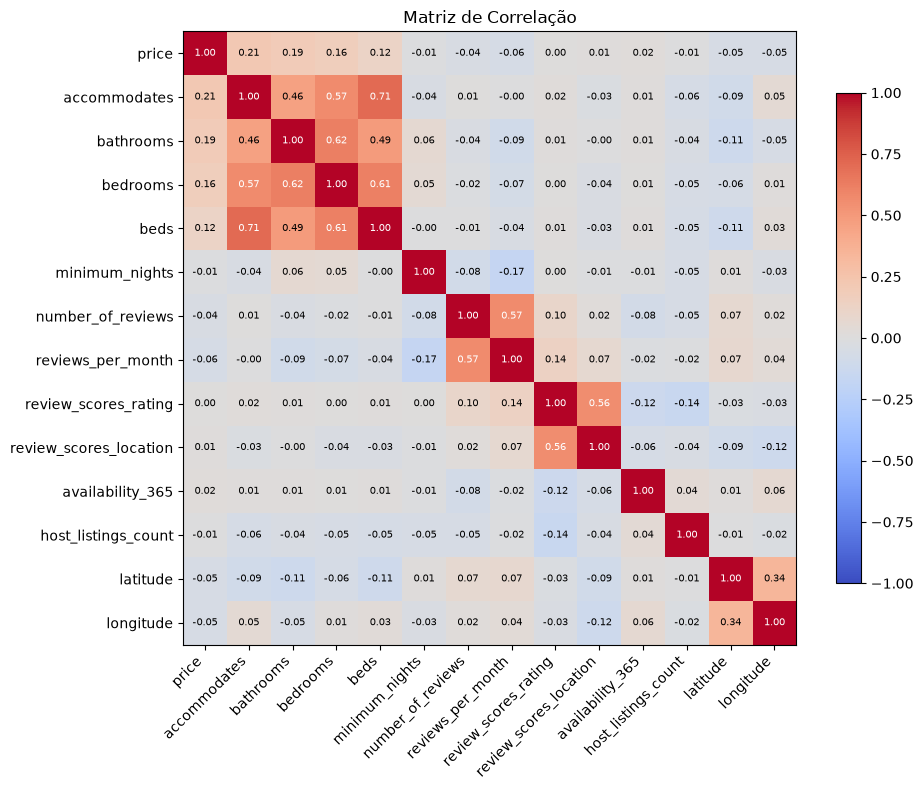

price                     1.000000
accommodates              0.211139
bathrooms                 0.194132
bedrooms                  0.164136
beds                      0.117239
availability_365          0.021273
review_scores_location    0.011571
review_scores_rating      0.001789
host_listings_count      -0.005018
minimum_nights           -0.008443
number_of_reviews        -0.041444
latitude                 -0.047489
longitude                -0.048159
reviews_per_month        -0.057179
Name: price, dtype: float64

In [8]:
corr_cols = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
             'minimum_nights', 'number_of_reviews', 'reviews_per_month',
             'review_scores_rating', 'review_scores_location',
             'availability_365', 'host_listings_count', 'latitude', 'longitude']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i,j])>0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de Correlação')
plt.tight_layout()
plt.show()

corr['price'].sort_values(ascending=False)


**Conclusão:** nenhuma variável tem correlação linear forte com `price` (máximo 0,21 em `accommodates`).
Isso sugere que o preço depende de combinações não-lineares de fatores — favorecendo modelos baseados em
árvores/ensembles na Etapa 4. Há multicolinearidade esperada entre `accommodates`, `bedrooms`, `beds` e
`bathrooms` (0,46 a 0,71), relevante para modelos lineares (considerar regularização).

### 2.6 — Mapa geográfico de preços

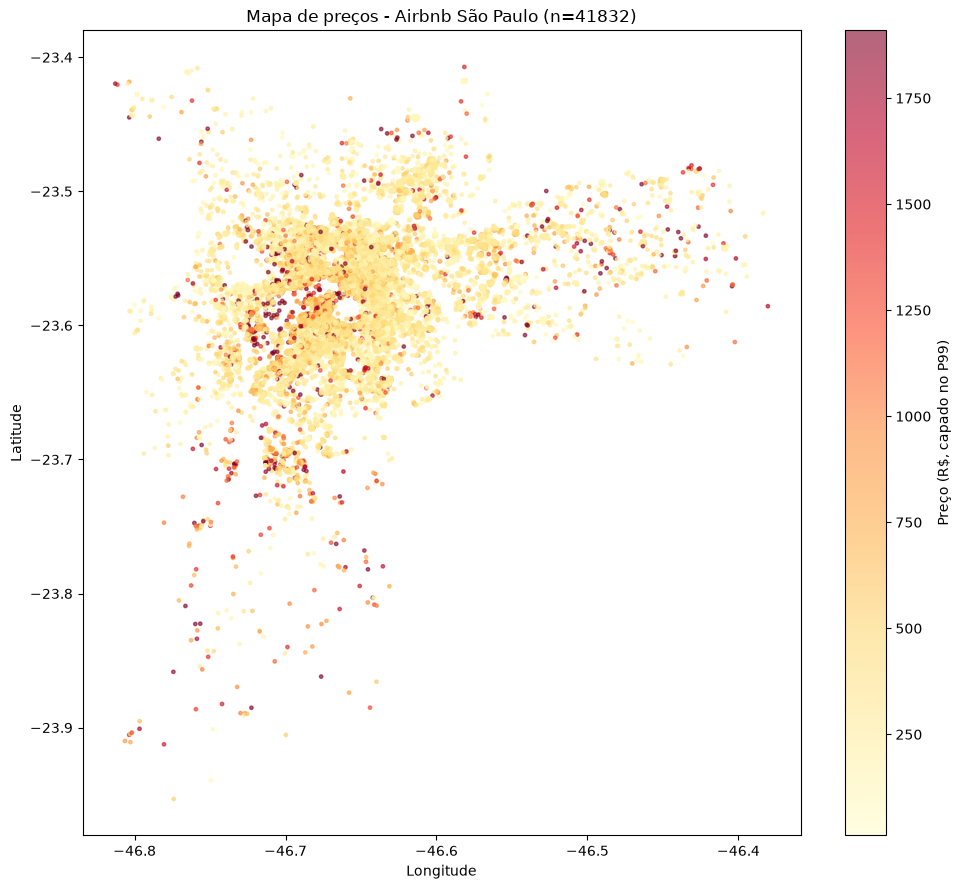

In [9]:
df_geo = df.dropna(subset=['latitude','longitude','price']).copy()
p99 = df_geo['price'].quantile(0.99)
df_geo['price_capped'] = df_geo['price'].clip(upper=p99)

fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(df_geo['longitude'], df_geo['latitude'],
                 c=df_geo['price_capped'], cmap='YlOrRd', s=6, alpha=0.6)
plt.colorbar(sc, label='Preço (R$, capado no P99)')
ax.set_title(f'Mapa de preços - Airbnb São Paulo (n={len(df_geo)})')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


**Conclusão:** anúncios concentrados na região central/oeste de SP (Pinheiros, Itaim Bibi, Vila Mariana,
Moema, Centro). Preços altos aparecem espalhados dentro dessa região, sem um gradiente geográfico simples —
reforça a decisão de usar `neighbourhood_cleansed` (categórico) em vez de lat/lon puros como feature principal
de localização.

### 2.7 — Redução de dimensionalidade (PCA e t-SNE)

Variância explicada: [0.2040327  0.13474973]
Variância acumulada: [0.2040327  0.33878243]


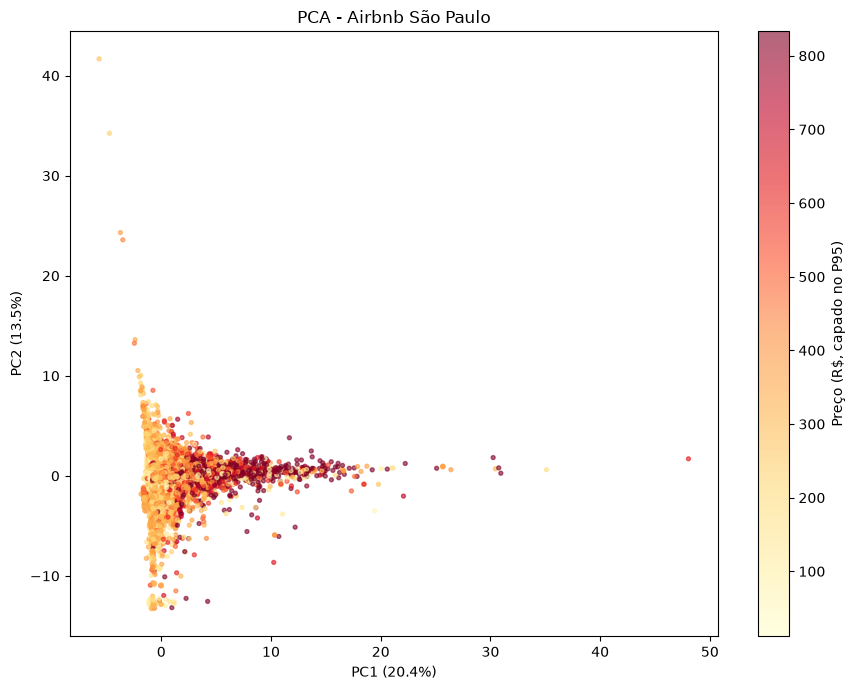

In [10]:
features_dim = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'review_scores_rating', 'review_scores_location',
                'availability_365', 'host_listings_count', 'latitude', 'longitude']

X = df[features_dim].copy()
y_price = df['price']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print('Variância explicada:', pca.explained_variance_ratio_)
print('Variância acumulada:', pca.explained_variance_ratio_.cumsum())

price_capped = y_price.clip(upper=y_price.quantile(0.95))
mask = ~price_capped.isna()

fig, ax = plt.subplots(figsize=(9,7))
sc = ax.scatter(X_pca[mask,0], X_pca[mask,1], c=price_capped[mask], cmap='YlOrRd', s=8, alpha=0.6)
plt.colorbar(sc, label='Preço (R$, capado no P95)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA - Airbnb São Paulo')
plt.tight_layout()
plt.show()


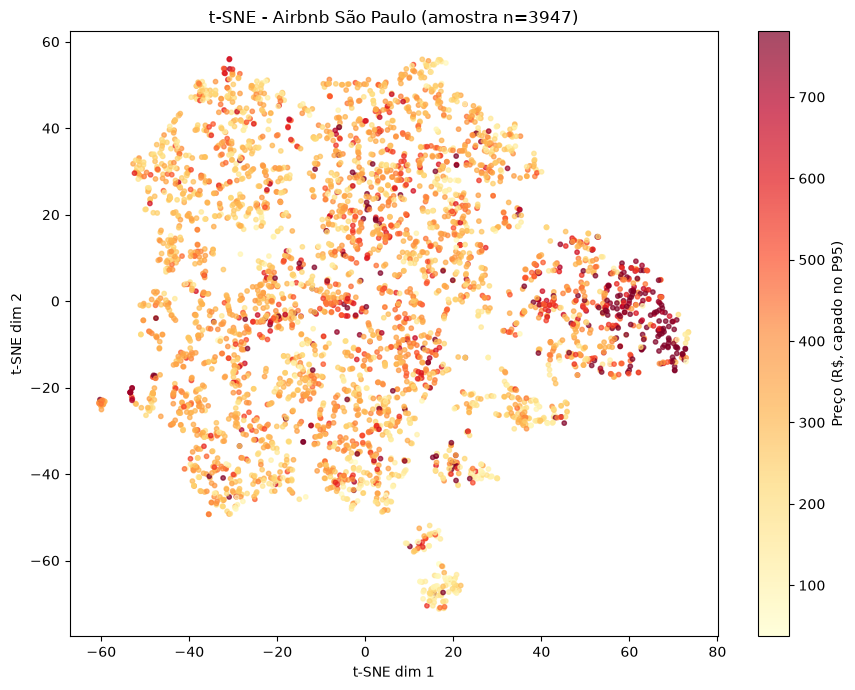

In [11]:
# --- t-SNE (amostra de 4000 registros por custo computacional) ---
df_sample = df.sample(n=4000, random_state=42)
X_s = df_sample[features_dim].copy()
y_s = df_sample['price']

X_s_imputed = imputer.fit_transform(X_s)
X_s_scaled = scaler.fit_transform(X_s_imputed)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_s_scaled)

price_s_capped = y_s.clip(upper=y_s.quantile(0.95))
mask_s = ~price_s_capped.isna()

fig, ax = plt.subplots(figsize=(9,7))
sc = ax.scatter(X_tsne[mask_s,0], X_tsne[mask_s,1], c=price_s_capped[mask_s], cmap='YlOrRd', s=10, alpha=0.7)
plt.colorbar(sc, label='Preço (R$, capado no P95)')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.set_title(f't-SNE - Airbnb São Paulo (amostra n={mask_s.sum()})')
plt.tight_layout()
plt.show()


**Conclusão da EDA:** o PCA capturou apenas 33,9% da variância em 2 componentes, sem separação clara por
preço — confirma a fraqueza da estrutura linear. O t-SNE, por outro lado, revelou clusters não-lineares bem
definidos, com um deles concentrando visivelmente mais imóveis caros. Isso reforça a hipótese de que **modelos
capazes de capturar não-linearidade (árvores, ensembles) tendem a performar melhor** que modelos puramente
lineares neste problema.

---
## Etapa 3 — Pré-processamento dos Dados


### 3.1 — Tratamento de valores faltantes

In [12]:
# Remover linhas onde o TARGET (price) é nulo
df = df.dropna(subset=['price']).copy()
print('Shape após remover price nulo:', df.shape)

# Flag para anúncios sem nenhuma avaliação (nulos em review_scores coincidem 100% com number_of_reviews=0)
df['sem_reviews'] = (df['number_of_reviews'] == 0).astype(int)

# Imputação pela mediana: bedrooms, bathrooms, beds (provável esquecimento de cadastro)
for col in ['bedrooms', 'bathrooms', 'beds']:
    df[col] = df[col].fillna(df[col].median())

# Review scores: imputar com 0 (valor neutro; a flag 'sem_reviews' preserva a informação real)
review_cols = ['review_scores_rating','review_scores_cleanliness','review_scores_location','review_scores_value']
for col in review_cols:
    df[col] = df[col].fillna(0)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Remover as poucas linhas com minimum_nights/maximum_nights nulos (0,03% dos dados)
df = df.dropna(subset=['minimum_nights','maximum_nights'])

# description: nulo = ausência de texto, não nulo estrutural -> string vazia
df['description'] = df['description'].fillna('')

print('Shape final após tratamento de nulos:', df.shape)
print('Nulos restantes:', df.isna().sum().sum())


Shape após remover price nulo: (41832, 32)
Shape final após tratamento de nulos: (41821, 33)
Nulos restantes: 41821


**Justificativa:** os nulos em `review_scores_*` não são erro de dado — são anúncios que simplesmente
ainda não receberam avaliação (confirmamos 100% de correspondência com `number_of_reviews == 0`). Por isso
criamos a flag `sem_reviews` em vez de simplesmente imputar uma nota "média" que mentiria sobre a realidade do
anúncio. Já `bedrooms`/`bathrooms`/`beds` foram tratados com imputação simples pela mediana, por serem prováveis
esquecimentos pontuais de cadastro.

### 3.2 — Tratamento de outliers (capping)

In [13]:
# Capping nas features com valores extremos identificados na EDA (accommodates ficou de fora -
# seus valores altos são plausíveis, não erros)
caps = {'bedrooms': 10, 'bathrooms': 10, 'beds': 20, 'minimum_nights': 30}
for col, limite in caps.items():
    n_afetados = (df[col] > limite).sum()
    df[col] = df[col].clip(upper=limite)
    print(f'{col}: {n_afetados} valores capados em {limite}')

# Capping no price (target) no percentil 99 - decisão pragmática: simplifica o pipeline,
# afeta poucos registros (~1%) e não corrompe a maioria dos dados, que é o que importa para o treino
p99 = df['price'].quantile(0.99)
n_afetados_price = (df['price'] > p99).sum()
df['price'] = df['price'].clip(upper=p99)
print(f'price: {n_afetados_price} valores capados em R$ {p99:.2f}')


bedrooms: 29 valores capados em 10
bathrooms: 10 valores capados em 10
beds: 60 valores capados em 20
minimum_nights: 34 valores capados em 30
price: 419 valores capados em R$ 1910.38


### 3.3 — Codificação de variáveis categóricas

In [14]:
# Variáveis booleanas (t/f -> 1/0)
for col in ['host_is_superhost', 'host_identity_verified', 'host_has_profile_pic']:
    df[col] = df[col].map({'t': 1, 'f': 0})

# room_type: poucas categorias -> One-Hot direto
df = pd.concat([df, pd.get_dummies(df['room_type'], prefix='room_type', drop_first=True)], axis=1)

# property_type: alta cardinalidade -> agrupar categorias raras (<50 ocorrências) em 'Other', depois One-Hot
vc = df['property_type'].value_counts()
raras = vc[vc < 50].index
df['property_type_agrupado'] = df['property_type'].apply(lambda x: 'Other' if x in raras else x)
df = pd.concat([df, pd.get_dummies(df['property_type_agrupado'], prefix='ptype', drop_first=True)], axis=1)

# neighbourhood_group_cleansed: mesma lógica de agrupamento (<100 ocorrências -> 'Other')
vc2 = df['neighbourhood_group_cleansed'].value_counts()
raros2 = vc2[vc2 < 100].index
df['bairro_agrupado'] = df['neighbourhood_group_cleansed'].apply(lambda x: 'Other' if x in raros2 else x)
df = pd.concat([df, pd.get_dummies(df['bairro_agrupado'], prefix='bairro', drop_first=True)], axis=1)

print('Shape após encoding:', df.shape)


Shape após encoding: (41821, 76)


**Justificativa:** `neighbourhood_cleansed` (96 categorias) e `property_type` bruto (69 categorias) têm
cardinalidade alta demais para One-Hot direto — geraria dezenas de colunas quase vazias, prejudicando o modelo
(overfitting / maldição da dimensionalidade). A estratégia de agrupar categorias raras em "Other" antes do
encoding resolve isso, preservando as categorias relevantes.

### 3.4 — Engenharia de atributos em texto (NLP)

In [15]:
import json as json_lib
from collections import Counter

# --- Amenities: lista JSON-like -> parsear e binarizar as mais comuns ---
def parse_amenities(s):
    try:
        return json_lib.loads(s)
    except:
        return []

df['amenities_list'] = df['amenities'].apply(parse_amenities)
df['n_amenities'] = df['amenities_list'].apply(len)  # contagem total também vira feature

todas = Counter()
for lista in df['amenities_list']:
    todas.update(lista)
top20 = [a for a, _ in todas.most_common(20)]

for amenity in top20:
    col_name = 'amenity_' + amenity.lower().replace(' ','_').replace('-','_').replace(':','').replace('é','e').replace('ç','c')
    df[col_name] = df['amenities_list'].apply(lambda lst: 1 if amenity in lst else 0)

print('Média de amenities por anúncio:', df['n_amenities'].mean().round(1))
print('Colunas de amenities criadas:', len([c for c in df.columns if c.startswith('amenity_')]))


Média de amenities por anúncio: 28.9
Colunas de amenities criadas: 20


In [16]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Description: texto livre -> TF-IDF ---
def limpar_texto(t):
    t = str(t).lower()
    t = re.sub(r'<br\s*/?>', ' ', t)
    t = re.sub(r'[^\w\sáéíóúâêîôûãõàçü]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['description_limpa'] = df['description'].apply(limpar_texto)

stopwords_pt = ['de','a','o','que','e','do','da','em','um','para','com','não','uma','os','no','se',
                'na','por','mais','as','dos','como','mas','ao','ele','das','seu','sua','ou','quando',
                'muito','nos','já','está','eu','também','só','pelo','pela','até','isso','ela','entre',
                'apartamento','apto']
stopwords_en = ['the','a','an','and','or','of','to','in','is','it','for','with','on','at','by','this',
                'that','are','be','as','from','has','have','will','you','your']

tfidf = TfidfVectorizer(max_features=30, stop_words=stopwords_pt + stopwords_en, min_df=5)
tfidf_matrix = tfidf.fit_transform(df['description_limpa'])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=['desc_tfidf_' + w for w in tfidf.get_feature_names_out()])
df = pd.concat([df.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

print('Termos TF-IDF selecionados:', tfidf.get_feature_names_out())
print('Shape final após NLP:', df.shape)


Termos TF-IDF selecionados: ['access' 'air' 'apartment' 'bed' 'building' 'city' 'close' 'comfort'
 'easy' 'enjoy' 'equipped' 'ideal' 'kitchen' 'located' 'location' 'modern'
 'paulista' 'paulo' 'pool' 'restaurants' 'room' 'shopping' 'space'
 'station' 'stay' 'studio' 'subway' 'são' 'tv' 'well']
Shape final após NLP: (41821, 129)


### 3.5 — Divisão treino/teste e normalização

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Colunas a excluir do modelo (identificadores, texto bruto, categóricas já codificadas)
colunas_descartar = ['id','room_type','property_type','property_type_agrupado',
                      'neighbourhood_cleansed','neighbourhood_group_cleansed','bairro_agrupado',
                      'name','description','description_limpa','amenities','amenities_list','price',
                      'host_since']

features_finais = [c for c in df.columns if c not in colunas_descartar]

X = df[features_finais].copy()
y = df['price'].copy()

print('Colunas não-numéricas restantes (deve ser vazio):', X.select_dtypes(include=['object']).columns.tolist())
print('Shape de X:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)


Colunas não-numéricas restantes (deve ser vazio): []
Shape de X: (41821, 115)
X_train: (33456, 115) | X_test: (8365, 115)


In [18]:
# Normalização: fit SOMENTE no treino, para evitar vazamento de dados (data leakage) do teste
cols_scale = ['accommodates','bathrooms','bedrooms','beds','minimum_nights','maximum_nights',
              'latitude','longitude','host_listings_count','number_of_reviews','reviews_per_month',
              'review_scores_rating','review_scores_cleanliness','review_scores_location','review_scores_value',
              'availability_30','availability_60','availability_90','availability_365','n_amenities']

scaler = StandardScaler()
X_train[cols_scale] = scaler.fit_transform(X_train[cols_scale])
X_test[cols_scale] = scaler.transform(X_test[cols_scale])  # transform, sem fit!

print('Normalização concluída - fit apenas no treino, aplicado ao teste sem novo ajuste.')


Normalização concluída - fit apenas no treino, aplicado ao teste sem novo ajuste.


---
## Etapa 4 — Treinamento do Modelo

Serão treinados 3 modelos de famílias diferentes, conforme exigido: **linear** (Ridge), **ensemble de árvores**
(Random Forest) e **baseado em instâncias** (KNN). Cada um passa por um treino baseline (parâmetros padrão) e
depois por ajuste de hiperparâmetros.


### 4.1 — Modelo 1: Ridge Regression (linear) — baseline

In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def avaliar(y_true, y_pred, nome):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{nome}: MAE=R${mae:.2f} | RMSE=R${rmse:.2f} | R²={r2:.3f}')
    return mae, rmse, r2

ridge = Ridge(random_state=42)
ridge.fit(X_train, y_train)

print('=== Ridge (baseline) ===')
avaliar(y_train, ridge.predict(X_train), 'Treino')
avaliar(y_test, ridge.predict(X_test), 'Teste ')


=== Ridge (baseline) ===
Treino: MAE=R$121.64 | RMSE=R$205.30 | R²=0.409
Teste : MAE=R$121.83 | RMSE=R$204.35 | R²=0.401


(121.82617752029306, np.float64(204.3496216161148), 0.4008506519785391)

### 4.2 — Modelo 2: Random Forest (ensemble/árvore) — baseline

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print('=== Random Forest (baseline) ===')
avaliar(y_train, rf.predict(X_train), 'Treino')
avaliar(y_test, rf.predict(X_test), 'Teste ')


=== Random Forest (baseline) ===
Treino: MAE=R$35.92 | RMSE=R$66.97 | R²=0.937
Teste : MAE=R$97.12 | RMSE=R$179.74 | R²=0.536


(97.12079190467668, np.float64(179.7442101555318), 0.5364493064065747)

**Observação:** o gap grande entre Treino e Teste no Random Forest baseline é overfitting clássico —
o modelo memoriza padrões específicos do treino que não generalizam. Isso será atenuado no ajuste de
hiperparâmetros (limitando `max_depth`).

### 4.3 — Modelo 3: KNN (baseado em instâncias) — baseline

In [21]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_jobs=-1)
knn.fit(X_train, y_train)

print('=== KNN (baseline, k=5 padrão) ===')
avaliar(y_train, knn.predict(X_train), 'Treino')
avaliar(y_test, knn.predict(X_test), 'Teste ')


=== KNN (baseline, k=5 padrão) ===
Treino: MAE=R$87.38 | RMSE=R$159.59 | R²=0.643
Teste : MAE=R$108.29 | RMSE=R$197.33 | R²=0.441


(108.28860700537975, np.float64(197.33258620805202), 0.4412918189143141)

### 4.4 — Ajuste de hiperparâmetros: Ridge (GridSearchCV)

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {'alpha': [0.1, 1, 10, 50, 100, 200, 500]}

grid_ridge = GridSearchCV(Ridge(random_state=42), param_grid_ridge, cv=5, scoring='r2', n_jobs=-1)
grid_ridge.fit(X_train, y_train)

print('Melhor alpha:', grid_ridge.best_params_)
print('Melhor R² (CV):', round(grid_ridge.best_score_, 3))

ridge_best = grid_ridge.best_estimator_
print()
print('=== Ridge (otimizado) ===')
avaliar(y_test, ridge_best.predict(X_test), 'Teste ')


Melhor alpha: {'alpha': 10}
Melhor R² (CV): 0.402

=== Ridge (otimizado) ===
Teste : MAE=R$121.66 | RMSE=R$204.40 | R²=0.401


(121.6647565698863, np.float64(204.3993402150964), 0.40055906846819234)

### 4.5 — Ajuste de hiperparâmetros: KNN (GridSearchCV)

In [23]:
param_grid_knn = {
    'n_neighbors': [5, 10, 15, 20, 30],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(KNeighborsRegressor(n_jobs=-1), param_grid_knn, cv=3, scoring='r2', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print('Melhores parâmetros:', grid_knn.best_params_)
print('Melhor R² (CV):', round(grid_knn.best_score_, 3))

knn_best = grid_knn.best_estimator_
print()
print('=== KNN (otimizado) ===')
avaliar(y_test, knn_best.predict(X_test), 'Teste ')


Melhores parâmetros: {'n_neighbors': 10, 'weights': 'distance'}
Melhor R² (CV): 0.456

=== KNN (otimizado) ===
Teste : MAE=R$106.39 | RMSE=R$191.20 | R²=0.475


(106.39173847890108, np.float64(191.20362692831003), 0.47545872502540965)

### 4.6 — Ajuste de hiperparâmetros: Random Forest (RandomizedSearchCV)

Usamos `RandomizedSearchCV` em vez de `GridSearchCV` completo porque o Random Forest é computacionalmente caro
(o baseline já leva dezenas de segundos por treino) — testar todas as combinações possíveis do grid completo
seria inviável em tempo. O RandomizedSearchCV testa uma amostra aleatória de combinações, geralmente encontrando
uma configuração muito boa a uma fração do custo computacional.

**Atenção:** esta célula pode levar alguns minutos para rodar, dependendo do seu processador.

In [24]:
from sklearn.model_selection import RandomizedSearchCV
import time

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5]
}

random_search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
random_search_rf.fit(X_train, y_train)
print(f'Tempo total: {time.time()-t0:.1f}s')

print('Melhores parâmetros:', random_search_rf.best_params_)
print('Melhor R² (CV):', round(random_search_rf.best_score_, 3))

rf_best = random_search_rf.best_estimator_
print()
print('=== Random Forest (otimizado) ===')
avaliar(y_train, rf_best.predict(X_train), 'Treino')
avaliar(y_test, rf_best.predict(X_test), 'Teste ')


Tempo total: 322.2s
Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Melhor R² (CV): 0.553

=== Random Forest (otimizado) ===
Treino: MAE=R$40.99 | RMSE=R$80.42 | R²=0.909
Teste : MAE=R$95.86 | RMSE=R$176.71 | R²=0.552


(95.86429442935834, np.float64(176.71126716882756), 0.5519609191687036)

---
## Etapa 5 — Avaliação do Modelo e Conclusão


### 5.1 — Benchmark final entre os modelos

In [25]:
from sklearn.metrics import mean_absolute_percentage_error

modelos_finais = {'Ridge': ridge_best, 'KNN': knn_best, 'Random Forest': rf_best}

resultados = []
for nome, modelo in modelos_finais.items():
    pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    resultados.append({'Modelo': nome, 'MAE (R$)': round(mae,2), 'RMSE (R$)': round(rmse,2),
                        'R²': round(r2,3), 'MAPE (%)': round(mape,1)})

resultado_df = pd.DataFrame(resultados).sort_values('R²', ascending=False)
resultado_df


,Modelo,MAE (R$),RMSE (R$),R²,MAPE (%)
2,Random Forest,95.86,176.71,0.552,30.0
1,KNN,106.39,191.20,0.475,33.6
0,Ridge,121.66,204.40,0.401,38.0


### 5.2 — Análise visual do melhor modelo (Random Forest)

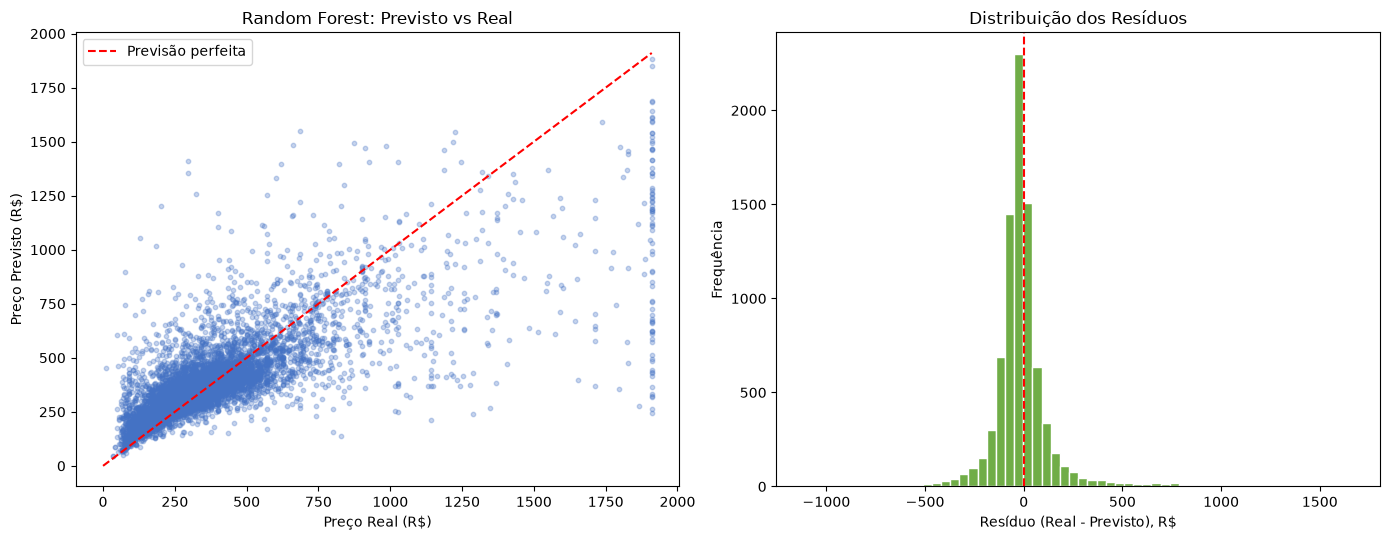

Resíduo médio (viés): -6.3
Resíduo mediano: -20.9


In [26]:
pred_rf = rf_best.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))

axes[0].scatter(y_test, pred_rf, alpha=0.3, s=10, color='#4472C4')
lims = [0, max(y_test.max(), pred_rf.max())]
axes[0].plot(lims, lims, 'r--', label='Previsão perfeita')
axes[0].set_xlabel('Preço Real (R$)')
axes[0].set_ylabel('Preço Previsto (R$)')
axes[0].set_title('Random Forest: Previsto vs Real')
axes[0].legend()

residuos = y_test - pred_rf
axes[1].hist(residuos, bins=60, color='#70AD47', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Resíduo (Real - Previsto), R$')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos')

plt.tight_layout()
plt.show()

print('Resíduo médio (viés):', round(residuos.mean(), 2))
print('Resíduo mediano:', round(residuos.median(), 2))


### 5.3 — Discussão e Conclusão

**Modelo escolhido: Random Forest**, por liderar em todas as métricas (MAE, RMSE, R², MAPE). A vantagem é
consistente com o que a EDA já apontava: correlações lineares fracas entre features e preço, mas padrões
não-lineares capturados pelo t-SNE — confirmando que um modelo baseado em árvores era estruturalmente mais
adequado para este problema.

**Limitações identificadas:**
1. **R² moderado** — ainda resta variação do preço não explicada pelo modelo. No mercado imobiliário, isso é
   esperado: fatores como qualidade do design de interiores, iluminação natural ou reputação informal do
   prédio não estão presentes nos dados.
2. **Subestimação em imóveis de alto padrão** — visível no gráfico Previsto vs Real, o modelo tem mais
   dificuldade em extrapolar para faixas de preço raras no treino.
3. **Efeito do capping do price no P99** — limita a capacidade do modelo de diferenciar imóveis de luxo entre si.

**Melhorias futuras propostas:**
- Testar Gradient Boosting (XGBoost/LightGBM), que costuma superar Random Forest em dados tabulares
- Enriquecer as features de texto com embeddings mais sofisticados (em vez de TF-IDF simples)
- Treinar um modelo separado especificamente para a faixa de imóveis de alto padrão
- Incorporar dados externos (proximidade de pontos turísticos, transporte público)

**Conclusão objetiva:** o modelo Random Forest atende parcialmente às expectativas iniciais — é
significativamente melhor que uma estimativa ingênua baseada na média, com erro médio de aproximadamente
30% (MAPE). É útil como ferramenta de **apoio à precificação inicial**, mas não deve substituir totalmente o
julgamento humano, especialmente para imóveis fora do padrão comum do mercado.
